In [1]:
from tqdm import tqdm
from modelseedpy_ext.re.hash_seq import HashSeq
import pymongo
def get_protein_hash(f):
    seq = f.seq
    if seq[-1] == '*':
        seq = seq[:-1]
    _h = HashSeq(seq).hash_value
    return _h

modelseedpy 0.4.3


In [8]:
%run modelseedpy_ext_salterns.py

In [16]:
import os
import json
from tqdm import tqdm
from modelseedpy import MSGenome
from modelseedpy_ext.re.hash_seq import HashSeq
import pymongo
mongo = pymongo.MongoClient('mongodb://poplar.cels.anl.gov:27017')
mongo_database = mongo['database']
c_protein_rast = mongo_database['protein_to_rast']

In [18]:
f_rast_cache = {}
g_cache = {}
def get_function_to_reads(path, read_kind):
    function_to_reads = {}
    for f in tqdm(os.listdir(path)):
        if f.endswith(f'.{read_kind}.cov.json'):
            with open(path + '/' + f, 'r') as fh:
                _data = json.load(fh)
            genome_fasta = f.split('.feature.')[0]
            genome = g_cache.get(genome_fasta)
            if genome is None:
                genome = MSGenome.from_fasta(f'/scratch/shared/CDM/salterns/data/All_MAGs_proteins/{genome_fasta}.faa')
                g_cache[genome_fasta] = genome
            genome = g_cache.get(genome_fasta)
            for k in _data:
                feature = genome.features.get_by_id(k)
                f_str = get_rast(feature)
                if f_str not in function_to_reads:
                    function_to_reads[f_str] = {'min': [], 'max': []}
                function_to_reads[f_str]['min'].append(_data[k][0])
                function_to_reads[f_str]['max'].append(_data[k][1])
    return function_to_reads
def get_rast(f):
    seq = f.seq
    if seq[-1] == '*':
        seq = seq[:-1]
    _h = HashSeq(seq).hash_value
    f_str = f_rast_cache.get(_h)
    if f_str is None:
        doc = c_protein_rast.find_one({'_id': _h})
        if doc['value'] is not None:
            f_str = '; '.join(doc['value'])
        else:
            f_str = 'hypothetical protein'
        f_rast_cache[_h] = f_str
    return f_str

In [20]:
def get_function_reads(f_to_reads, kind='min'):
    function_min_reads = {}
    for f in tqdm(f_to_reads):
        total = sum(f_to_reads[f]['min'])
        function_min_reads[f] = total
    function_min_reads_sorted = sorted(function_min_reads, key=lambda k: function_min_reads[k], reverse=True)
    return function_min_reads, function_min_reads_sorted

In [21]:
cov_kind = {'derep'}
sample_to_kind = {}
for sample_id in os.listdir('/scratch/shared/CDM/salterns/reads/cov/'):
    if sample_id[0] == 'R' or sample_id[0] == 'S':
        sample_to_kind[sample_id] = {}
        path = f'/scratch/shared/CDM/salterns/reads/cov/{sample_id}/'
        print(sample_id, path)
        for kind in cov_kind:
            f_to_reads = get_function_to_reads(path, kind)
            derep_min_f, derep_min_f_skeys = get_function_reads(f_to_reads, 'min')
            sample_to_kind[sample_id][kind] = [derep_min_f, derep_min_f_skeys]

R1_A_D1_MG /scratch/shared/CDM/salterns/reads/cov/R1_A_D1_MG/


100%|██████████| 11038/11038 [00:00<00:00, 830926.42it/s]


R1_A_D2_MG /scratch/shared/CDM/salterns/reads/cov/R1_A_D2_MG/


100%|██████████| 11130/11130 [00:00<00:00, 612688.88it/s]


R1_A_H2O_MG /scratch/shared/CDM/salterns/reads/cov/R1_A_H2O_MG/


...

100%|██████████| 7966/7966 [00:00<00:00, 663815.50it/s]


SF2_C_D2_MG /scratch/shared/CDM/salterns/reads/cov/SF2_C_D2_MG/


100%|██████████| 8757/8757 [00:00<00:00, 642809.99it/s]


SF2_C_H2O_MG /scratch/shared/CDM/salterns/reads/cov/SF2_C_H2O_MG/


100%|██████████| 6958/6958 [00:00<00:00, 738703.70it/s]


In [38]:
by_sample_class = {}
for sample in sample_to_kind:
    if sample in sample_class:
        s_class = sample_class[sample]
        if s_class not in by_sample_class:
            by_sample_class[s_class] = {}
        for role, read_count in sample_to_kind[sample]['derep'][0].items():
            if 'anaerobic dimethyl' in role.lower() or 'trimethylamine-n-oxide'  in role.lower():
                if read_count > 0:
                    if role not in by_sample_class[s_class]:
                        by_sample_class[s_class][role] = 0
                    by_sample_class[s_class][role] += read_count

In [41]:
for c in by_sample_class:
    print(c)
    for role, ct in by_sample_class[c].items():
        print('\t', role, ct)

unrestored
	 Anaerobic dimethyl sulfoxide reductase chain B (EC 1.8.5.3), iron-sulfur binding subunit 110
	 Anaerobic dimethyl sulfoxide reductase chain A (EC 1.8.5.3), molybdopterin-binding domain 245
	 Trimethylamine-N-oxide reductase (EC 1.6.6.9) 61
	 Anaerobic dimethyl sulfoxide reductase chain B (EC 1.8.5.3), iron-sulfur binding subunit;  Respiratory trimethylamine-N-oxide reductase, iron-sulfur subunit 33
	 Anaerobic dimethyl sulfoxide reductase chain A (EC 1.8.5.3), molybdopterin-binding domain;  Trimethylamine-N-oxide reductase (EC 1.6.6.9) 24
restored
	 Anaerobic dimethyl sulfoxide reductase chain A (EC 1.8.5.3), molybdopterin-binding domain 24
	 Anaerobic dimethyl sulfoxide reductase chain B (EC 1.8.5.3), iron-sulfur binding subunit 25
	 Anaerobic dimethyl sulfoxide reductase chain C (EC 1.8.5.3), anchor subunit 4
	 Anaerobic dimethyl sulfoxide reductase chaperone DmsD 1
	 Trimethylamine-N-oxide reductase (EC 1.6.6.9) 145
	 Trimethylamine-N-oxide reductase (EC 1.7.2.3), TorA 

In [9]:
pan_analysis = PanGenomeAnalysis()
pan_analysis.load_all_genomes()
pan_analysis.load_taxonomy()
pan_analysis.load_motupan()

AttributeError: 'NoneType' object has no attribute 'features'

In [8]:
pan_analysis.load_motupan_genomes()

In [3]:
print(len(pan_analysis.genomes))

1959


In [5]:
print(len(pan_analysis.clade_motupan))

59


In [6]:
print(len(pan_analysis.taxonomy))

310


In [9]:
print(len(pan_analysis.clade_to_genome))

59


In [16]:
for clade_id in pan_analysis.clade_motupan:
    clade_taxa = pan_analysis.get_clade_taxonomy(clade_id)
    if len(clade_taxa) == 0:
        print(clade_id, len(pan_analysis.clade_to_genome[clade_id]))

Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.59.contigs 2
Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.94.contigs 2
TAOJ22-1_SAMN27365858_MAG_00000074 46
Salt_Pond_MetaG_R2_B_D1_MG_DASTool_bins_metabat.8.contigs 2


In [32]:
import pymongo
mongo = pymongo.MongoClient('mongodb://sequoia.mcs.anl.gov:27017')
mongo_database = mongo['database']
c_protein_rast = mongo_database['protein_to_rast']
protein_hash_to_rast = {}
all_rast_functions = set()
for doc in tqdm(c_protein_rast.find()):
    if doc['value'] is not None:
        f_str = '; '.join(doc['value'])
        protein_hash_to_rast[doc['_id']] = '; '.join(doc['value'])
        all_rast_functions.add(f_str)

2445078it [00:24, 100627.28it/s]


In [21]:
derep_genomes = set()
with open('/home/fliu/cliff_mags/data/ani_library_derep_mags.txt', 'r') as fh:
    for l in fh.readlines():
        genome_id = l.strip().split('/')[-1][:-3]
        genome = pan_analysis.get_genome_faa(genome_id)
        if genome:
            derep_genomes.add(genome_id)

In [23]:
len(derep_genomes)

310

In [62]:
import json
with open('/home/fliu/cliff_mags/data/read_to_function_score_dereps.json', 'r') as fh:
    sample_to_bin_score_derep = json.load(fh)

In [80]:
sample_to_bin_rank_derep = {}
for sample_id in sample_to_bin_score_derep:
    bin_scores = sample_to_bin_score_derep[sample_id]
    sample_to_bin_rank_derep[sample_id] = {}
    rev_keys = list(sorted(bin_scores, key=lambda k: bin_scores[k], reverse=True))
    for i in range(len(rev_keys)):
        sample_to_bin_rank_derep[sample_id][rev_keys[i]] = i + 1

_temp = {}
for sample_id in sample_to_bin_rank_derep:
    bin_ranks = sample_to_bin_rank_derep[sample_id]
    for genome_id in bin_ranks:
        if genome_id not in _temp:
            _temp[genome_id] = []
        _temp[genome_id].append(bin_ranks[genome_id])
all_sample_bin_rank_derep = {k: min(ranks) for k, ranks in _temp.items()}

In [112]:
sample_to_bin_per_derep = {}
for sample_id in sample_to_bin_score_derep:
    bin_scores = sample_to_bin_score_derep[sample_id]
    total_score = sum(list(bin_scores.values()))
    sample_to_bin_per_derep[sample_id] = {k: v/total_score for k, v in bin_scores.items()}

In [114]:
rows = []
header = ['bin', 'gtdb_d', 'gtdb_p', 'gtdb_c', 'gtdb_o', 'gtdb_f']
for sample_id in sample_ids:
    header.append(f'bin_all_{sample_id}_per')
for genome_bin_id in derep_genomes:
    #genome_bin = pan_analysis.get_genome_faa(genome_bin_id)
    if genome_bin_id in pan_analysis.taxonomy:
        _taxa = pan_analysis.taxonomy[genome_bin_id].split(';')
        row = [genome_bin_id, _taxa[0], _taxa[1], _taxa[2], _taxa[3], _taxa[4]]
        for sample_id in sample_ids:
            row.append(sample_to_bin_per_derep[sample_id].get(genome_bin_id, 0))
        rows.append(row)
    else:
        #print('?', genome_bin_id, ct_bin_functions, ct_bin_pan_core, ct_bin_core_functions, ct_bin_core_missing)
        pass

In [115]:
import pandas as pd
df = pd.DataFrame(rows, columns=header).set_index('bin')
df.to_csv('./data/gsp_bin_sample_perc.tsv', sep='\t')

In [91]:
rows = []
header = ['bin', 'gtdb_d', 'gtdb_p', 'gtdb_c', 'gtdb_o', 'gtdb_f', 'n_rast', 'n_pangenome_core', 'n_bin_core', 'n_bin_miss_core', 'bin_all_sample_rank']
for sample_id in sample_ids:
    header.append(f'bin_all_{sample_id}_rank')
for genome_bin_id in derep_genomes:
    genome_bin = pan_analysis.get_genome_faa(genome_bin_id)
    if genome_bin_id in pan_analysis.genome_to_clade:
        bin_motopan_data = pan_analysis.clade_motupan[pan_analysis.genome_to_clade[genome_bin_id]]
        bin_functions = set(protein_hash_to_rast.get(get_protein_hash(f)) for f in genome_bin.features)
        core_functions = set()
        for feature_id in bin_motopan_data['core']:
            feature_genome = pan_analysis.genomes.get(pan_analysis.feature_to_genome.get(feature_id))
            if feature_genome:
                feature_core = feature_genome.features.get_by_id(feature_id)
                core_functions.add(protein_hash_to_rast.get(get_protein_hash(feature_core)))
        ct_bin_functions = len(bin_functions)
        ct_bin_pan_core = len(core_functions)
        ct_bin_core_functions = len(bin_functions & core_functions)
        ct_bin_core_missing = len(core_functions - bin_functions)
        if genome_bin_id in pan_analysis.taxonomy:
            _taxa = pan_analysis.taxonomy[genome_bin_id].split(';')
            row = [genome_bin_id, _taxa[0], _taxa[1], _taxa[2], _taxa[3], _taxa[4], ct_bin_functions, ct_bin_pan_core, ct_bin_core_functions, ct_bin_core_missing, all_sample_bin_rank_derep[genome_bin_id]]
            for sample_id in sample_ids:
                row.append(sample_to_bin_rank_derep[sample_id].get(genome_bin_id, -1))
            rows.append(row)
        else:
            #print('?', genome_bin_id, ct_bin_functions, ct_bin_pan_core, ct_bin_core_functions, ct_bin_core_missing)
            pass

In [97]:
import pandas as pd
df = pd.DataFrame(rows, columns=header).set_index('bin')

In [99]:
df.to_csv('./data/gsp_analysis.tsv', sep='\t')

In [52]:
for genome_bin_id in derep_genomes:
    #genome_bin_id = 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.21.contigs'
    genome_bin = pan_analysis.get_genome_faa(genome_bin_id)


Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.21.contigs 985 927 927 0
Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.57.contigs 1205 927 507 420
Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.36.contigs 1386 927 531 396
Salt_Pond_MetaG_R2A_C_D2_MG_DASTool_bins_metabat.38.contigs 1344 927 486 441
Salt_Pond_MetaG_R2A_B_D2_MG_DASTool_bins_concoct_out.54.contigs 1083 927 463 464
Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.25.contigs 1664 927 596 331
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.71.contigs 1645 927 589 338
Salt_Pond_MetaG_R2_B_H2O_MG_DASTool_bins_metabat.29.contigs 213 927 86 841
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs 1752 927 588 339
Salt_Pond_MetaG_R2_restored_DShore_MG_DASTool_bins_concoct_out.37.contigs 854 927 219 708
Salt_Pond_MetaGSF2_B_D2_MG_DASTool_bins_concoct_out.42.contigs 868 927 541 386
Salt_Pond_MetaG_R2A_C_H2O_MG_DASTool_bins_metabat.5.contigs 1540 927 529 398
Salt_Pond_MetaG_R2_A

In [134]:
for genome_bin_id in derep_genomes:
    if genome_bin_id in pan_analysis.taxonomy:
        genome_bin = pan_analysis.get_genome_faa(genome_bin_id)
        bin_functions = set(protein_hash_to_rast.get(get_protein_hash(f)) for f in genome_bin.features)
        
        _taxa = pan_analysis.taxonomy[genome_bin_id].split(';')
        
        if genome_bin_id in pan_analysis.genome_to_clade:
            clade_id = pan_analysis.genome_to_clade[genome_bin_id]
            bin_motopan_data = pan_analysis.clade_motupan[clade_id]

            aux_functions = set()
            for clade_member in pan_analysis.clade_to_genome[clade_id]:
                genome_clade_member = pan_analysis.get_genome_faa(clade_member)
                genome_clade_member_functions = set(protein_hash_to_rast.get(get_protein_hash(f)) for f in genome_clade_member.features)
                aux_functions |= genome_clade_member_functions

            core_functions = set()
            for feature_id in bin_motopan_data['core']:
                feature_genome = pan_analysis.genomes.get(pan_analysis.feature_to_genome.get(feature_id))
                if feature_genome:
                    feature_core = feature_genome.features.get_by_id(feature_id)
                    core_functions.add(protein_hash_to_rast.get(get_protein_hash(feature_core)))

            aux_functions -= core_functions

                
            for protein_id in proteins_scan:
                for rast_f in proteins_scan[protein_id]:
                    is_core = rast_f in core_functions
                    is_base = rast_f in bin_functions
                    is_aux = rast_f in aux_functions
                    is_aug = not is_base and is_core
                    is_aug_maybe = not is_base and is_aux
                    if is_core or is_aux:
                        row = [genome_bin_id, _taxa[0], _taxa[1], _taxa[2], _taxa[3], _taxa[4], protein_id, rast_f, is_aux, is_core, is_base, is_aug, is_aug_maybe]
                        print('\t'.join([str(x) for x in row]))
        else:
            for protein_id in proteins_scan:
                for rast_f in proteins_scan[protein_id]:
                    is_core = '?'
                    is_base = rast_f in bin_functions
                    is_aux = '?'
                    is_aug = '?'
                    is_aug_maybe = '?'
                    if is_base:
                        row = [genome_bin_id, _taxa[0], _taxa[1], _taxa[2], _taxa[3], _taxa[4], protein_id, rast_f, is_aux, is_core, is_base, is_aug, is_aug_maybe]
                        print('\t'.join([str(x) for x in row]))

Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.36.contigs	d__Bacteria	p__Planctomycetota	c__Planctomycetes	o__Pirellulales	f__Pirellulaceae	ProWVX	Glycine betaine/L-proline transport ATP-binding protein ProV (TC 3.A.1.12.1)	?	?	True	?	?
Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.36.contigs	d__Bacteria	p__Planctomycetota	c__Planctomycetes	o__Pirellulales	f__Pirellulaceae	OpuABC	Glycine betaine ABC transport system, glycine betaine-binding protein OpuAC	?	?	True	?	?
Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.36.contigs	d__Bacteria	p__Planctomycetota	c__Planctomycetes	o__Pirellulales	f__Pirellulaceae	OpuABC	Glycine betaine ABC transport system, permease protein OpuAB	?	?	True	?	?
Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.36.contigs	d__Bacteria	p__Planctomycetota	c__Planctomycetes	o__Pirellulales	f__Pirellulaceae	sar_demet	Glycine N-methyltransferase (EC 2.1.1.20);  Sarcosine N-methyltransferase (EC 2.1.1.157)	?	?	True	?	?
Salt_Pond_MetaG_R2_restored_C_blac

'Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_concoct_out.34.contigs'

# How many CORE/AUX functions hit reads

In [153]:
bin_score = {}
read_kind = 'derep'
for genome_bin_id in derep_genomes:
    #genome_bin_id = 'Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_concoct_out.34.contigs'
    genome = pan_analysis.get_genome_faa(genome_bin_id)
    for sample_id in sample_ids:
        bin_score[genome_bin_id] = {}
        for sample_id in sample_ids:
            feature_score = {}
            filename_cov = f'/scratch/shared/CDM/salterns/reads/cov/{sample_id}/{genome_bin_id}.feature.{read_kind}.cov.json'
            if os.path.exists(filename_cov):
                with open(filename_cov) as fh:
                    cov_data = json.load(fh)
                    for feature_id, score in cov_data.items():
                        if feature_id in genome.features:
                            _score = score[0]
                            if _score:
                                feature_score[feature_id] = _score
                        else:
                            print('feature not found')
            bin_score[genome_bin_id][sample_id] = feature_score

In [200]:
pan_score = {}
for read_kind in {'rep', 'ext'}:
    for sample_id in tqdm(sample_ids):
        for filename_cov in os.listdir(f'/scratch/shared/CDM/salterns/reads/cov/{sample_id}/'):
            if filename_cov.endswith(f'.{read_kind}.cov.json'):
                genome_id = filename_cov.split('.feature.')[0]
                genome = pan_analysis.get_genome_faa(genome_id)
                if genome:
                    if genome_id not in pan_score:
                        pan_score[genome_id] = {}
                    if sample_id not in pan_score[genome_id]:
                        pan_score[genome_id][sample_id] = {}
                    with open(f'/scratch/shared/CDM/salterns/reads/cov/{sample_id}/{filename_cov}') as fh:
                        cov_data = json.load(fh)
                        for feature_id, score in cov_data.items():
                            if feature_id in genome.features:
                                _score = score[0]
                                if _score:
                                    if feature_id not in pan_score[genome_id][sample_id]:
                                        pan_score[genome_id][sample_id][feature_id] = 0
                                    pan_score[genome_id][sample_id][feature_id] += _score
                        #print(cov_data)
                else:
                    print(f'not found {genome_id}')
        #filename_cov = f'/scratch/shared/CDM/salterns/reads/cov/{sample_id}/{genome_bin_id}.feature.{read_kind}.cov.json'
        #if os.path.exists(filename_cov):

100%|██████████| 33/33 [01:04<00:00,  1.94s/it]


In [ ]:
pan_analysis.genomes['Salt_Pond_MetaGSF2_C_D1_MG_DASTool_bins_metabat.11.contigs']

In [ ]:
from collections import Counter

In [316]:
rows = []
for genome_bin_id in tqdm(derep_genomes):
    if genome_bin_id in pan_analysis.taxonomy and genome_bin_id in pan_analysis.genome_to_clade:
        clade_id = pan_analysis.genome_to_clade[genome_bin_id]
        genome_bin = pan_analysis.get_genome_faa(genome_bin_id)
        bin_functions = set(protein_hash_to_rast.get(get_protein_hash(f)) for f in genome_bin.features)
        
        bin_motopan_data = pan_analysis.clade_motupan[pan_analysis.genome_to_clade[genome_bin_id]]
        core_functions = set()
        for feature_id in bin_motopan_data['core']:
            feature_genome = pan_analysis.genomes.get(pan_analysis.feature_to_genome.get(feature_id))
            if feature_genome:
                feature_core = feature_genome.features.get_by_id(feature_id)
                core_functions.add(protein_hash_to_rast.get(get_protein_hash(feature_core)))
                
        aux_functions = set()
        for clade_member in pan_analysis.clade_to_genome[clade_id]:
            genome_clade_member = pan_analysis.get_genome_faa(clade_member)
            genome_clade_member_functions = set(protein_hash_to_rast.get(get_protein_hash(f)) for f in genome_clade_member.features)
            aux_functions |= genome_clade_member_functions
            
        aux_functions -= core_functions
                
        bin_function_score = {}
        for sample_id in bin_score[genome_bin_id]:
            #if sample_id in bin_score[genome_bin_id]:
            feature_score = bin_score[genome_bin_id][sample_id]
            for f_id, s in feature_score.items():
                if f_id in genome_bin.features:
                    f = genome_bin.features.get_by_id(f_id)        
                    rast_str = protein_hash_to_rast.get(get_protein_hash(f))
                    if rast_str not in bin_function_score:
                        bin_function_score[rast_str] = 0
                    bin_function_score[rast_str] += s
                
        bin_core_score = 0
        bin_aux_score = 0
        for rast_str, score in bin_function_score.items():
            if rast_str and rast_str != 'hypothetical protein':
                if rast_str not in core_functions:
                    bin_aux_score += score
                else:
                    bin_core_score += score
                    
        all_features = set()
        for clade_member in pan_analysis.clade_to_genome[clade_id]:
            genome_clade_member = pan_analysis.get_genome_faa(clade_member)
            all_features |= {f.id for f in  genome_clade_member.features}
        aux_features = all_features - set(bin_motopan_data['core'])
        len(all_features), len(aux_features)
                    
        aux_feature_score = {}
        for f in aux_features:
            genome_id = pan_analysis.feature_to_genome.get(f)
            if genome_id:
                feature_score = 0
                pan_score_genome = pan_score.get(genome_id)
                if pan_score_genome:
                    for sample_id in pan_score_genome:
                        feature_score += pan_score_genome[sample_id].get(f, 0)

                bin_score_genome = bin_score.get(genome_id)
                if bin_score_genome:
                    for sample_id in bin_score_genome:
                        feature_score += bin_score_genome[sample_id].get(f, 0)
                
                if feature_score != 0:
                    aux_feature_score[f] = feature_score
                    
        core_feature_score = {}
        for f in bin_motopan_data['core']:
            genome_id = pan_analysis.feature_to_genome.get(feature_id)
            if genome_id:
                feature_score = 0
                pan_score_genome = pan_score.get(genome_id)
                if pan_score_genome:
                    for sample_id in pan_score_genome:
                        feature_score += pan_score_genome[sample_id].get(f, 0)

                bin_score_genome = bin_score.get(genome_id)
                if bin_score_genome:
                    for sample_id in bin_score_genome:
                        feature_score += bin_score_genome[sample_id].get(f, 0)
                
                if feature_score != 0:
                    core_feature_score[f] = feature_score
                    
        bin_core_functions = bin_functions & core_functions
        bin_aux_functions = bin_functions - core_functions
        pan_new_core_functions = core_functions - bin_functions
        pan_new_aux_functions = aux_functions - bin_functions
        
        aux_recruited_rast_score = Counter()
        aux_recruited_feature_score = {}
        for feature_id in aux_feature_score:
            genome_id = pan_analysis.feature_to_genome.get(feature_id)
            aux_genome = pan_analysis.get_genome_faa(genome_id)
            if aux_genome:
                feature = aux_genome.features.get_by_id(feature_id)
                rast_str = protein_hash_to_rast.get(get_protein_hash(feature))
                if rast_str not in bin_functions:
                    aux_recruited_feature_score[feature_id] = aux_feature_score[feature_id]
                    aux_recruited_rast_score.update({rast_str: aux_feature_score[feature_id]})
                    
        row = [genome_bin_id, bin_core_score, bin_aux_score, sum(aux_recruited_rast_score.values())]
        rows.append(row)

100%|██████████| 310/310 [00:46<00:00,  6.71it/s]


In [322]:
rows

[['Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.21.contigs', 6, 0, 0],
 ['Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.87.contigs',
  28074,
  10752,
  3858],
 ['Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_concoct_out.44.contigs',
  93308,
  17786,
  15158],
 ['Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.20.contigs',
  11772,
  10812,
  293],
 ['Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.119.contigs',
  9173,
  2388,
  523],
 ['Salt_Pond_MetaG_R2A_C_D2_MG_DASTool_bins_concoct_out.42.contigs',
  16721,
  2590,
  1560],
 ['Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_concoct_out.67.contigs',
  38695,
  24025,
  1743],
 ['Salt_Pond_MetaG_R2_A_H2O_MG_DASTool_bins_metabat.14.contigs',
  48348,
  2549,
  596],
 ['Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_concoct_out.109.contigs',
  3763,
  3008,
  1206],
 ['Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.143.contigs',
  9587,
  15800,
  0],
 ['Salt_Pond_MetaG_R2A_B_H2O_MG_DASTool_bins_metabat.42.contigs',
  66061,

In [321]:
df = pd.DataFrame(rows, columns=['bin', 'bin_core_score', 'bin_aux_score', 'bin_aux_pan_score']).set_index('bin')
df

,bin_core_score,bin_aux_score,bin_aux_pan_score
bin,,,
Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.21.contigs,6,0,0
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.87.contigs,28074,10752,3858
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_concoct_out.44.contigs,93308,17786,15158
Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.20.contigs,11772,10812,293
Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.119.contigs,9173,2388,523
Salt_Pond_MetaG_R2A_C_D2_MG_DASTool_bins_concoct_out.42.contigs,16721,2590,1560
Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_concoct_out.67.contigs,38695,24025,1743
Salt_Pond_MetaG_R2_A_H2O_MG_DASTool_bins_metabat.14.contigs,48348,2549,596
Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_concoct_out.109.contigs,3763,3008,1206


In [311]:
genome_id in pan_score

False

/opt/env/python3_modelseed/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/env/python3_modelseed/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/opt/env/python3_modelseed/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/env/python3_modelseed/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: Series

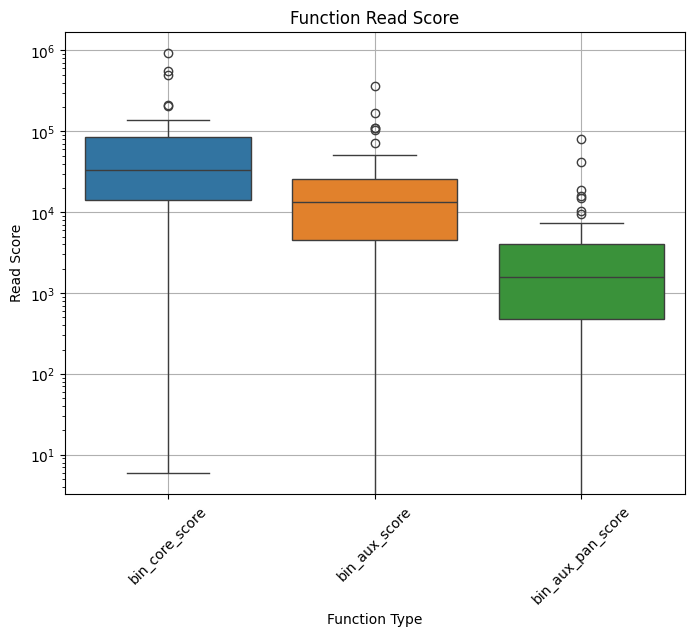

In [327]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Function Read Score")
plt.ylabel("Read Score")
plt.xlabel("Function Type")
plt.yscale('log')
plt.grid(True)
plt.show()

In [328]:
len(rows)

54

1309

In [275]:
aux_recruited_feature_score

{'NODE_549_length_45656_cov_3.99222_34': 3,
 'NODE_53_length_144185_cov_4.06883_118': 2,
 'NODE_966_length_32313_cov_3.45961_12': 2,
 'NODE_877_length_34490_cov_3.94724_2': 3,
 'NODE_2200_length_18371_cov_4.2722_3': 10,
 'NODE_1644_length_22856_cov_4.80246_5': 1,
 'NODE_380_length_56768_cov_3.88505_24': 3,
 'NODE_3250_length_13955_cov_3.67183_5': 2,
 'NODE_3690_length_12799_cov_2.08665_2': 2,
 'NODE_18406_length_4057_cov_1.19898_5': 7,
 'NODE_268_length_70068_cov_4.06035_39': 4,
 'NODE_20582_length_3744_cov_1.46807_2': 39,
 'NODE_1566_length_23528_cov_3.20392_17': 9,
 'NODE_1569_length_23512_cov_3.12127_3': 9,
 'NODE_18406_length_4057_cov_1.19898_2': 20,
 'NODE_18406_length_4057_cov_1.19898_1': 5,
 'NODE_1566_length_23528_cov_3.20392_16': 1,
 'NODE_1691_length_22441_cov_3.08645_2': 16,
 'NODE_53_length_144185_cov_4.06883_114': 3,
 'NODE_691_length_39298_cov_3.40653_35': 4,
 'NODE_549_length_45656_cov_3.99222_35': 4,
 'NODE_1882_length_20682_cov_3.47589_11': 10,
 'NODE_3690_length_12799

In [258]:
for f in bin_motopan_data['core']:
    print(f, pan_analysis.feature_to_genome.get(f))

NODE_10393_length_4854_cov_1.46266_3 Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.31.contigs
NODE_849_length_28634_cov_2.83053_3 Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.31.contigs
NODE_2028_length_20696_cov_4.71297_8 Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_concoct_out.112.contigs
NODE_1097_length_24488_cov_3.2176_19 Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.31.contigs
NODE_387_length_56285_cov_3.8845_10 Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.3.contigs
NODE_1566_length_23528_cov_3.20392_2 Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.3.contigs
NODE_1358_length_25870_cov_3.93816_18 Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.3.contigs
NODE_327_length_62498_cov_3.59167_39 Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.3.contigs
NODE_3992_length_12772_cov_4.34116_9 Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_concoct_out.112.contigs
NODE_26659_length_2531_cov_1.43719_3 Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.31.contigs
NODE_1373_length_25

In [263]:
{k: v for k, v in core_feature_score.items() if k in genome_bin.features}

{}

In [268]:
for k in core_feature_score.keys():
    print(k, k in genome_bin.features)

NODE_387_length_56285_cov_3.8845_10 False
NODE_1566_length_23528_cov_3.20392_2 False
NODE_1358_length_25870_cov_3.93816_18 False
NODE_327_length_62498_cov_3.59167_39 False
NODE_3250_length_13955_cov_3.67183_11 False
NODE_1023_length_30968_cov_4.3676_21 False
NODE_65_length_132156_cov_4.11669_114 False
NODE_908_length_33773_cov_4.25816_7 False
NODE_13077_length_5156_cov_2.93537_4 False
NODE_53_length_144185_cov_4.06883_121 False
NODE_387_length_56285_cov_3.8845_17 False
NODE_208_length_78713_cov_3.62162_52 False
NODE_579_length_44187_cov_3.65606_9 False
NODE_1882_length_20682_cov_3.47589_8 False
NODE_575_length_44337_cov_3.48654_19 False
NODE_1023_length_30968_cov_4.3676_26 False
NODE_5078_length_10209_cov_2.14303_8 False
NODE_1358_length_25870_cov_3.93816_7 False
NODE_1566_length_23528_cov_3.20392_6 False
NODE_1222_length_27396_cov_4.56408_5 False
NODE_1373_length_25676_cov_3.24001_12 False
NODE_1358_length_25870_cov_3.93816_21 False
NODE_549_length_45656_cov_3.99222_37 False
NODE_1358

In [251]:
{f.id for f in genome_bin.features}

{'NODE_7205_length_8314_cov_1.69097_4',
 'NODE_28607_length_2882_cov_1.99819_2',
 'NODE_8258_length_7505_cov_1.07834_10',
 'NODE_5237_length_10504_cov_1.63843_7',
 'NODE_6023_length_9485_cov_1.55728_7',
 'NODE_2895_length_16045_cov_1.42769_14',
 'NODE_9427_length_6746_cov_1.90165_6',
 'NODE_12007_length_5595_cov_1.61668_4',
 'NODE_4895_length_11044_cov_2.0491_9',
 'NODE_8018_length_7668_cov_1.2383_2',
 'NODE_25101_length_3177_cov_1.34_4',
 'NODE_26795_length_3023_cov_1.01105_1',
 'NODE_8082_length_7628_cov_1.51726_7',
 'NODE_13875_length_4998_cov_1.12051_5',
 'NODE_19787_length_3789_cov_1.13244_4',
 'NODE_6023_length_9485_cov_1.55728_9',
 'NODE_17844_length_4105_cov_1.56536_3',
 'NODE_12515_length_5416_cov_1.74154_2',
 'NODE_10740_length_6106_cov_1.25774_2',
 'NODE_10763_length_6090_cov_1.44558_2',
 'NODE_6023_length_9485_cov_1.55728_2',
 'NODE_16496_length_4368_cov_1.03207_4',
 'NODE_30402_length_2758_cov_1.53668_1',
 'NODE_22898_length_3403_cov_1.79579_2',
 'NODE_12047_length_5581_co

In [262]:
set(bin_motopan_data['core']) & {f.id for f in }

{'NODE_10024_length_6431_cov_1.4908_3',
 'NODE_10166_length_6364_cov_1.89065_4',
 'NODE_10242_length_6333_cov_2.61392_2',
 'NODE_10242_length_6333_cov_2.61392_3',
 'NODE_10242_length_6333_cov_2.61392_4',
 'NODE_10248_length_6331_cov_1.84155_4',
 'NODE_10255_length_6329_cov_0.956143_3',
 'NODE_10255_length_6329_cov_0.956143_5',
 'NODE_10616_length_6160_cov_1.61147_2',
 'NODE_10687_length_6126_cov_1.74346_7',
 'NODE_10857_length_6053_cov_1.10513_2',
 'NODE_10857_length_6053_cov_1.10513_3',
 'NODE_10857_length_6053_cov_1.10513_4',
 'NODE_10905_length_6033_cov_1.66221_2',
 'NODE_10905_length_6033_cov_1.66221_3',
 'NODE_10905_length_6033_cov_1.66221_4',
 'NODE_10905_length_6033_cov_1.66221_5',
 'NODE_11058_length_5966_cov_1.61432_3',
 'NODE_11083_length_5953_cov_1.97751_2',
 'NODE_11083_length_5953_cov_1.97751_5',
 'NODE_11241_length_5892_cov_1.4144_3',
 'NODE_11241_length_5892_cov_1.4144_4',
 'NODE_11241_length_5892_cov_1.4144_5',
 'NODE_11241_length_5892_cov_1.4144_6',
 'NODE_11289_length

In [242]:
{x for x in core_feature_score if x in genome_bin.features}

set()

In [214]:
for clade_member in pan_analysis.clade_to_genome[clade_id]:
    genome_clade_member = pan_analysis.get_genome_faa(clade_member)
    print(clade_member, clade_member in derep_genomes)
    break

Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.35.contigs False


(11513, 10005)

In [210]:
print('bin', len(bin_functions), len(bin_functions & core_functions), len(bin_functions - core_functions))
print('pan', len(core_functions | aux_functions), len(core_functions), len(aux_functions))

bin 1387 899 488
pan 1871 900 971


In [167]:
bin_function_score

{None: 55,
 'hypothetical protein': 5,
 'Chemotaxis protein methyltransferase CheR (EC 2.1.1.80)': 4,
 'Chemotaxis response regulator protein-glutamate methylesterase CheB (EC 3.1.1.61)': 2}

In [ ]:
for genome_bin_id in derep_genomes:
    if genome_bin_id in pan_analysis.taxonomy:
        genome_bin = pan_analysis.get_genome_faa(genome_bin_id)
        bin_functions = set(protein_hash_to_rast.get(get_protein_hash(f)) for f in genome_bin.features)

In [33]:
sample_class = {
    'R1_A_D1_MG': 'unrestored',
    'R1_B_D1_MG': 'unrestored',
'R2_A_D1_MG': 'unrestored',
'R2_B_D1_MG': 'unrestored',
'R2_C_D1_MG': 'unrestored',

'R1_A_D2_MG': 'unrestored',
'R1_B_D2_MG': 'unrestored',
'R1_C_D2_MG': 'unrestored',
'R2_B_D2_MG': 'unrestored',

'R1_A_H2O_MG': 'unrestored',
'R1_B_H2O_MG': 'unrestored',
'R2_B_H2O_MG': 'unrestored',
'R2_C_H2O_MG': 'unrestored',

'R2A_A_D1_MG': 'restored',
'R2A_B_D1_MG': 'restored',
'R2A_C_D1_MG': 'restored',

'R2A_A_D2_MG': 'restored',
'R2A_B_D2_MG': 'restored',
'R2A_C_D2_MG': 'restored',

'R2A_A_H2O_MG': 'restored',
'R2A_B_H2O_MG': 'restored',
'R2A_C_H2O_MG': 'restored',

'SF2_B_D1_MG': 'wetland',
'SF2_C_D1_MG': 'wetland',

'SF2_A_D2_MG': 'wetland',
'SF2_B_D2_MG': 'wetland',
'SF2_C_D2_MG': 'wetland',

'SF2_A_H2O_MG': 'wetland',
'SF2_B_H2O_MG': 'wetland',
'SF2_C_H2O_MG': 'wetland',
            }

In [152]:
sample_ids = ['R1_A_D1_MG',
'R1_B_D1_MG',
'R2_A_D1_MG',
'R2_B_D1_MG',
'R2_C_D1_MG',

'R1_A_D2_MG',
'R1_B_D2_MG',
'R1_C_D2_MG',
'R2_B_D2_MG',

'R1_A_H2O_MG',
'R1_B_H2O_MG',
'R2_B_H2O_MG',
'R2_C_H2O_MG',

'R2_restored_C_black_MG',
'R2_restored_D_shore_MG',
'R2_restored_H2O_MG',

'R2A_A_D1_MG',
'R2A_B_D1_MG',
'R2A_C_D1_MG',

'R2A_A_D2_MG',
'R2A_B_D2_MG',
'R2A_C_D2_MG',

'R2A_A_H2O_MG',
'R2A_B_H2O_MG',
'R2A_C_H2O_MG',

'SF2_B_D1_MG',
'SF2_C_D1_MG',

'SF2_A_D2_MG',
'SF2_B_D2_MG',
'SF2_C_D2_MG',

'SF2_A_H2O_MG',
'SF2_B_H2O_MG',
'SF2_C_H2O_MG']

In [116]:
proteins_scan = {
    'ProWVX': [
        'Glycine betaine/L-proline transport substrate-binding protein ProX (TC 3.A.1.12.1)',
        'Glycine betaine/L-proline transport system permease protein ProW (TC 3.A.1.12.1)',
        'Glycine betaine/L-proline transport ATP-binding protein ProV (TC 3.A.1.12.1)'
    ],
    'OpuABC': [
        'Glycine betaine ABC transport system, glycine betaine-binding protein OpuAC',
        'Glycine betaine ABC transport system, ATP-binding protein OpuAA (EC 3.6.3.32)',
        'Glycine betaine ABC transport system, permease protein OpuAB'
    ],
    'OtaABC': [
        'Glycine betaine ABC transporter, ATP-binding protein OtaA',
        'Glycine betaine ABC transporter, permease protein OtaB',
        'Glycine betaine ABC transporter, substrate-binding protein OtaC'
    ],
    'bet_trans': [
        'Glycine betaine transporter'
    ],
    'dmgly_to_bet': [
       'Dimethylglycine N-methyltransferase (EC 2.1.1.161)' 
    ],
    'bet_reductase': [
        'Betaine reductase component B beta subunit (EC 1.21.4.4);  selenocysteine-containing',
        'Betaine reductase component B beta subunit (EC 1.21.4.4)',
        'Betaine reductase component B alpha subunit (EC 1.21.4.4)'
    ],
    'gbsA': [
        'Betaine aldehyde dehydrogenase (EC 1.2.1.8)',
    ],
    'gbsB': [
        'Alcohol dehydrogenase GbsB (type III ), essential for the utilization of choline (EC 1.1.1.1)'
    ],
    'gly_bet_sar_reductase': [
        'Glycine/sarcosine/betaine reductase protein A;  selenocysteine-containing',
        'Glycine/sarcosine/betaine reductase component C chain 1',
        'Glycine/sarcosine/betaine reductase component C chain 2'
    ],
    'phnCDE': [
        'Phosphonate ABC transporter substrate-binding protein PhnD (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter permease protein PhnE (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter permease protein PhnE2 (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter permease protein PhnE1 (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter ATP-binding protein PhnC (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter permease protein PhnE2 (TC 3.A.1.9.1); Phosphonate ABC transporter permease protein PhnE1 (TC 3.A.1.9.1)',
    ],
    'phnI': [
        'Alpha-D-ribose 1-methylphosphonate 5-triphosphate synthase subunit PhnI (EC 2.7.8.37)'
    ],
    'phnM': [
        'Alpha-D-ribose 1-methylphosphonate 5-triphosphate diphosphatase (EC 3.6.1.63)'
    ],
    'phnJ': [
        'Alpha-D-ribose 1-methylphosphonate 5-phosphate C-P lyase (EC 4.7.1.1)'
    ],
    'phnN': [
        'Ribose 1,5-bisphosphate phosphokinase PhnN (EC 2.7.4.23)',
    ],
    'sar_demet':
    [
        'Sarcosine N-methyltransferase (EC 2.1.1.157)',
        'Glycine N-methyltransferase (EC 2.1.1.20);  Sarcosine N-methyltransferase (EC 2.1.1.157)',
        'Glycine N-methyltransferase (EC 2.1.1.20);  Sarcosine N-methyltransferase (EC 2.1.1.157); Sarcosine N-methyltransferase (EC 2.1.1.157);  Dimethylglycine N-methyltransferase (EC 2.1.1.161)',
    ],
    'tma_corr': [
        'Trimethylamine methyltransferase family protein',
        'Trimethylamine methyltransferase corrinoid protein',
        'trimethylamine methyltransferase MttB',
        'Trimethylamine methyltransferase mttB (EC 2.1.1.-) (TMA methyltransferase)',
        'trimethylamine methyltransferase'
    ],
    'mcom': [
        'Methyl coenzyme M reductase gamma subunit (EC 2.8.4.1)',
        'Methyl coenzyme M reductase alpha subunit (EC 2.8.4.1)',
        'Methyl coenzyme M reductase beta subunit (EC 2.8.4.1)',
    ]
}
proteins_scan_all_functions = set()
for k, s in proteins_scan.items():
    proteins_scan_all_functions |= set(s)

In [351]:
import pymongo
mongo = pymongo.MongoClient('mongodb://sequoia.mcs.anl.gov:27017')
mongo_database = mongo['database']
c_protein_rast = mongo_database['protein_to_rast']
rast_to_genome_feature = {}
for genome_id in tqdm(derep_genomes):
    genome = pan_analysis.get_genome_faa(genome_id)
    if genome:
        for f in genome.features:
            h = get_protein_hash(f)
            doc = c_protein_rast.find_one({'_id': h})
            rast_l = doc['value']
            if rast_l == None:
                rast_l = ['hypothetical protein']
            for rast in rast_l:
                if rast not in rast_to_genome_feature:
                    rast_to_genome_feature[rast] = {}
                if genome_id not in rast_to_genome_feature[rast]:
                    rast_to_genome_feature[rast][genome_id] = set()
                rast_to_genome_feature[rast][genome_id].add(f.id)
    else:
        print('!')

100%|██████████| 310/310 [09:06<00:00,  1.76s/it]


In [368]:
f_phn = {
    'phnI': [
        'Alpha-D-ribose 1-methylphosphonate 5-triphosphate synthase subunit PhnI (EC 2.7.8.37)'
    ],
    'phnM': [
        'Alpha-D-ribose 1-methylphosphonate 5-triphosphate diphosphatase (EC 3.6.1.63)'
    ],
    'phnJ': [
        'Alpha-D-ribose 1-methylphosphonate 5-phosphate C-P lyase (EC 4.7.1.1)'
    ],
    'phnN': [
        'Ribose 1,5-bisphosphate phosphokinase PhnN (EC 2.7.4.23)',
    ],
    'bet_reductase': [
        'Betaine reductase component B beta subunit (EC 1.21.4.4);  selenocysteine-containing',
        'Betaine reductase component B beta subunit (EC 1.21.4.4)',
        'Betaine reductase component B alpha subunit (EC 1.21.4.4)'
    ],
    'mttB': [
        'trimethylamine methyltransferase MttB',
        'Trimethylamine methyltransferase mttB (EC 2.1.1.-) (TMA methyltransferase)',
    ]
    #'Thioredoxin': ['Thioredoxin']
}
rows = []
for prot in f_phn:
    for rast_str in f_phn[prot]:
        filter_genome_features = rast_to_genome_feature.get(rast_str, {})
        for genome_id in filter_genome_features:
            genome = pan_analysis.get_genome_faa(genome_id)
            for feature_id in filter_genome_features[genome_id]:
                feature = genome.features.get_by_id(feature_id)
                ss = [genome_id, feature_id, prot, rast_str, pan_analysis.taxonomy.get(genome_id), feature.seq]
                rows.append(ss)
df_phn_betred_mmtb = pd.DataFrame(rows, columns=['genome_id', 'feature_id', 'protein', 'rast', 'taxa', 'sequence'])

In [369]:
df_phn_betred_mmtb.to_csv('./data/phn_betred_mmtb_functions_prodigal_genomes.tsv', sep='\t')

In [358]:
for k in rast_to_genome_feature:
    if '1.21.4.4' in k :
        print(k)

Betaine reductase component B alpha subunit (EC 1.21.4.4)
Betaine reductase component B beta subunit (EC 1.21.4.4)


In [ ]:

protein_hash_to_rast = {}
all_rast_functions = set()
for doc in tqdm(c_protein_rast.find()):
    if doc['value'] is not None:
        f_str = '; '.join(doc['value'])
        protein_hash_to_rast[doc['_id']] = '; '.join(doc['value'])
        all_rast_functions.add(f_str)

In [392]:
import pysam
import pymongo
mongo_client = pymongo.MongoClient('mongodb://sequoia.mcs.anl.gov:27017')
mongo_project = mongo_client['salterns']

In [414]:
sample_ids = ['R2_B_H2O_MG',
 'R2_C_D1_MG',
 'R2_C_H2O_MG',
 'R2_restored_C_black_MG',
 'R2_restored_D_shore_MG',
 'R2_restored_H2O_MG',]

In [ ]:
import pysam
import pymongo
mongo_client = pymongo.MongoClient('mongodb://sequoia.mcs.anl.gov:27017')
mongo_project = mongo_client['salterns']

for sample_id in sample_ids:
    filename_bam = f'/scratch/fliu/data/cliff/reads/coverm/{sample_id}/bins/coverm-genome.{sample_id}_1.fastq.bam'
    filename_bam_index = filename_bam + '.index'
    c = mongo_project[f'reads_{sample_id}_bins']
    with pysam.AlignmentFile(filename_bam, "rb", index_filename=filename_bam_index) as fh_sam:
        reads = []
        for read in fh_sam.fetch():
            doc_read = c.find_one({'_id': read.qname})
            if doc_read is None:
                reads.append({
                        '_id': read.qname,
                        'blocks': read.get_blocks(),
                        'sequence': read.seq,
                        'tags': read.tags,
                        'reference_name': read.reference_name,
                        'aligned_pairs': read.get_aligned_pairs(),
                        'is_paired': read.is_paired,
                        'is_mapped': read.is_mapped,
                        'is_read1': read.is_read1,
                        'is_read2': read.is_read2,
                        'is_qcfail': read.is_qcfail,
                        'is_reverse': read.is_reverse,
                    })
            if len(reads) >= 100:
                c.insert_many(reads)
                reads = []
        if len(reads) >= 0:
            c.insert_many(reads)

In [389]:
c

Collection(Database(MongoClient(host=['sequoia.mcs.anl.gov:27017'], document_class=dict, tz_aware=False, connect=True), 'salterns'), 'reads_R1_B_D1_MG_bins')

In [379]:
mongo_project.list_collection_names()

['reads_R1_A_D2_MG',
 'reads_R1_B_D1_MG_bins',
 'reads_R1_A_H2O_MG',
 'reads_R1_A_D1_MG',
 'contig',
 'assembly']

In [410]:
samples_ids = ['R1_A_D1_MG',
 'R1_A_D2_MG',
 'R1_A_H2O_MG',
 'R1_B_D1_MG',]
for sample_id in samples_ids:
    c = mongo_project[f'reads_{sample_id}_bins']
    #doc = c.find_one()
    #print(doc['_id'])
    print(sample_id, c.estimated_document_count())

R1_A_D1_MG 26136341
R1_A_D2_MG 25448272
R1_A_H2O_MG 15843538
R1_B_D1_MG 28011074


In [ ]:
mongo_project.list_collection_names()

In [406]:
c = mongo_project['reads_R1_A_D2_MG']
c.estimated_document_count()

48327

In [403]:
c.rename('reads_R1_A_H2O_MG_bins')

{'ok': 1.0}

In [ ]:
1